In [50]:
# ===============================
# Standard Library Imports
# ===============================
import warnings
from collections import Counter

# Suppress deprecation warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


# ===============================
# Third-Party Library Imports
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from wordcloud import WordCloud

# Gensim for topic modeling
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel

# Visualization library for LDA models
import pyLDAvis
import pyLDAvis.gensim


# ===============================
# Custom Module Imports
# ===============================
from saniia.data_loading import load_huffpost_data
from saniia.text_preprocessing import preprocess_text
from saniia.constants import HUFFPOST_DATA_PATH
from saniia.utc_split import split_dataframe
from saniia.evaluation import get_dominant_topic,get_ranked_predictions_mapping,top_k_accuracy,mean_reciprocal_rank


# Text Pre-processing

In [ ]:
# Load data
df_news = load_huffpost_data(HUFFPOST_DATA_PATH)

# Parallel PreprocessinG
df_news['headline'] = Parallel(n_jobs=-1, backend='threading')(
    delayed(preprocess_text)(text) for text in df_news['headline']
)
df_news['headline'] = df_news['headline'].apply(lambda x: x.split(" ") if isinstance(x, str) else [])


Number of articles: 209527
Number of topics: 42


## Summary Statistics

In [82]:
nb_articles=len(df_news)
print("Number of articles:", nb_articles)
true_categories = df_news['category'].unique()
num_topics=int(len(true_categories))
print("Number of topics:", num_topics)

df_news['len_headline']=df_news['headline'].apply(lambda x: len(x))

print("Average number of tokenized words per headline is", df_news['len_headline'].mean(),"±",df_news['len_headline'].std() )

Number of articles: 209527
Number of topics: 42
Average number of tokenized words per headline is 6.283266595713202 ± 2.3621058652573694


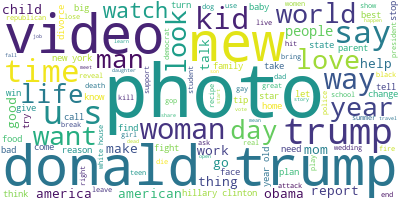

In [59]:
# Import the wordcloud library
from wordcloud import WordCloud
# Join the different processed titles together.
from itertools import chain

long_string =",".join(list(chain.from_iterable(df_news['headline'])))
# long_string = ','.join(list(df_news['headline'].values))
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=3, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(long_string)
# Visualize the word cloud
wordcloud.to_image()

# Data Split and Simple Baseline

/var/folders/24/zlb4r8b5367c79snzz14gnbc0000gn/T/ipykernel_2864/3190755801.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(categories), palette="viridis")
/opt/miniconda3/envs/saniia/lib/python3.9/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/opt/miniconda3/envs/saniia/lib/python3.9/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  

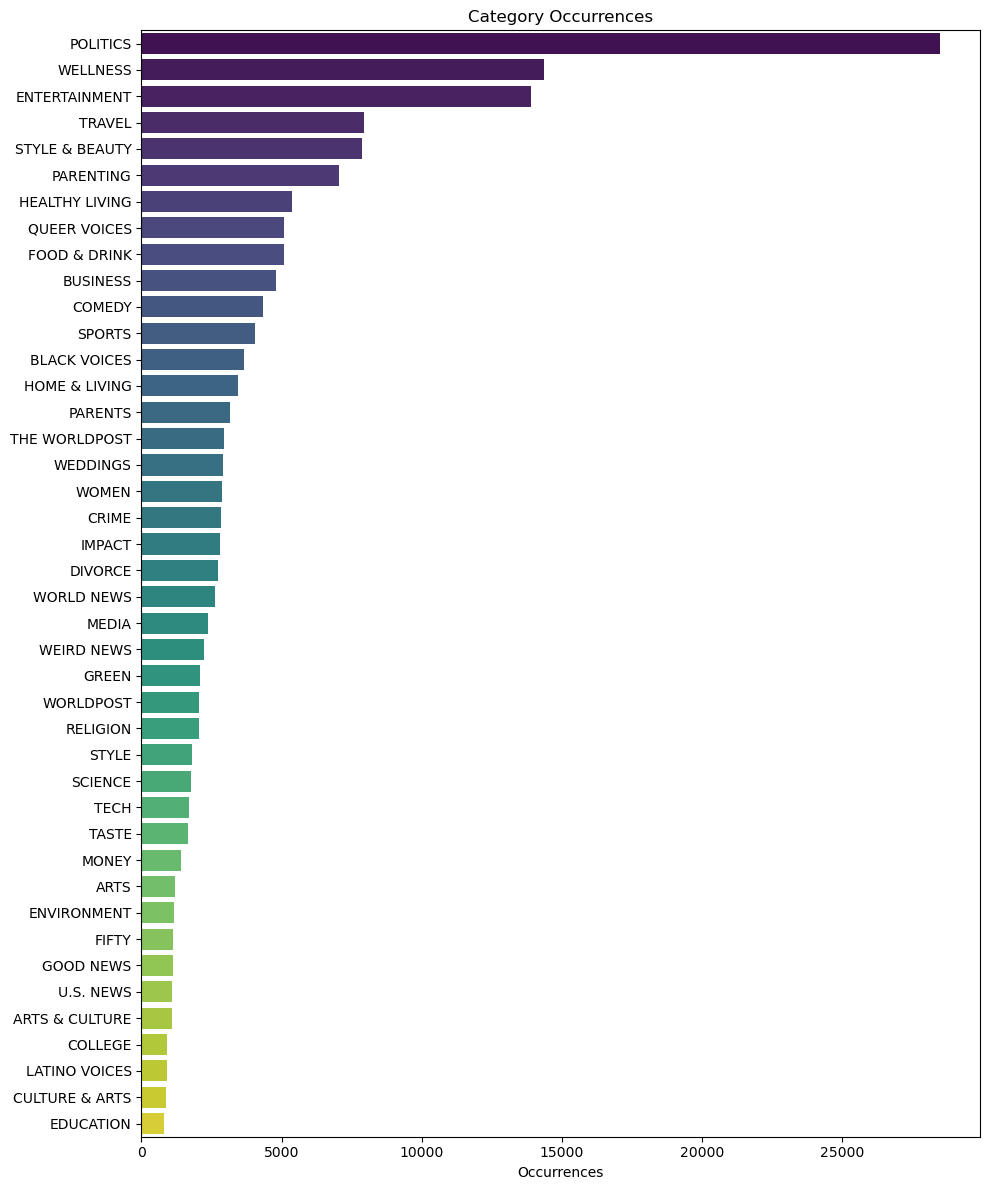

The baseline (majority class) algorithm corresponds to an accuracy of 0.1699279339474061


In [40]:
df_train,df_test=split_dataframe(df_news,stratify_col='category')

category_counts=Counter(df_train['category'])
# Sort the counter by count (descending order)
sorted_items = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)
categories, counts = zip(*sorted_items)  # unzip into separate lists

# Create a horizontal bar plot
plt.figure(figsize=(10, 12))
sns.barplot(x=list(counts), y=list(categories), palette="viridis")
plt.xlabel("Occurrences")
plt.title("Category Occurrences")
plt.tight_layout()
plt.show()

accuracy_baseline=(df_test['category']=='POLITICS').mean()
print(f'The baseline (majority class) algorithm corresponds to an accuracy of {accuracy_baseline}')


# Training Unsupervised Learning Algorithm

## Building Corpus

In [41]:
data_words=df_train['headline'].to_list()

# Create the dictionary and corpus for this text field
id2word = corpora.Dictionary(data_words)
id2word.filter_extremes(no_below=10, no_above=0.5)
corpus = [id2word.doc2bow(text) for text in data_words]

In [ ]:
# Define your seeds and the number of passes to test
seeds = [32, 42, 52]
nb_passes = [1, 2, 3, 4, 5]

# List to store the results as dictionaries for easy plotting later
results = []

# Loop over each seed and each number of passes
for seed in seeds:
    for num_passes in nb_passes:
        lda_model = gensim.models.ldamodel.LdaModel(
            corpus=corpus,
            id2word=id2word,
            num_topics=num_topics,
            random_state=seed,
            chunksize=1000,
            passes=num_passes,
            iterations=100,
            alpha="auto",
            eta="auto",
            eval_every=None
        )

        coherence_model_lda = CoherenceModel(
            model=lda_model,
            texts=data_words,
            dictionary=id2word,
            coherence='u_mass'
        )
        coherence_lda = coherence_model_lda.get_coherence()

        # Append results with current seed, number of passes, and coherence score
        results.append({
            "seed": seed,
            "passes": num_passes,
            "coherence": coherence_lda
        })

        print(f"Seed: {seed} | Passes: {num_passes} | Coherence Score: {coherence_lda}")

KeyboardInterrupt: 

/opt/miniconda3/envs/saniia/lib/python3.9/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/opt/miniconda3/envs/saniia/lib/python3.9/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])


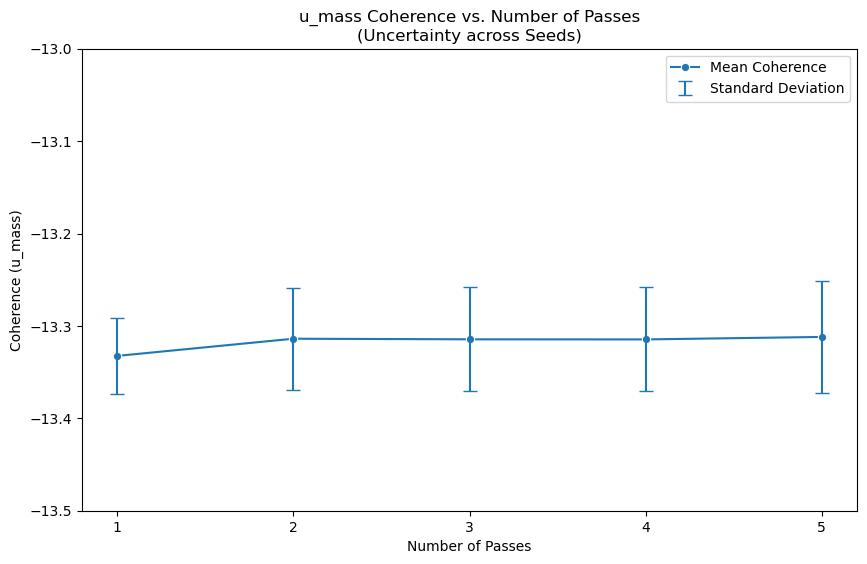

In [36]:
# Convert the list of results into a DataFrame for processing
df_results = pd.DataFrame(results)

# Group the results by number of passes to compute mean and standard deviation of coherence scores
df_grouped = df_results.groupby("passes", as_index=False).agg(
    mean_coherence=("coherence", "mean"),
    std_coherence=("coherence", "std")
)

# Plot the mean coherence with error bars indicating uncertainty (standard deviation)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_grouped, x="passes", y="mean_coherence", marker="o", label="Mean Coherence")
plt.errorbar(
    df_grouped["passes"],
    df_grouped["mean_coherence"],
    yerr=df_grouped["std_coherence"],
    fmt='none',
    capsize=5,
    color='tab:blue',
    label="Standard Deviation"
)

plt.xlabel("Number of Passes")
plt.ylabel("Coherence (u_mass)")
plt.title("u_mass Coherence vs. Number of Passes\n(Uncertainty across Seeds)")
plt.xticks(nb_passes)
plt.ylim([-13.5,-13])
plt.legend()
plt.show()

In [38]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds="mmds", R=10)
vis

/opt/miniconda3/envs/saniia/lib/python3.9/site-packages/pyLDAvis/_prepare.py:228: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info  = pd.DataFrame({'saliency': saliency, 'Term': vocab, \
/opt/miniconda3/envs/saniia/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
/opt/miniconda3/envs/saniia/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
37    -0.120498 -0.368302       1        1  4.227468
39    -0.086249 -0.493818       2        1  3.972594
3      0.011961  0.512137       3        1  3.227271
12    -0.308504  0.145213       4        1  3.142600
24    -0.508409  0.113581       5        1  3.105130
28    -0.328000 -0.394971       6        1  3.020297
32     0.042681 -0.518796       7        1  2.994233
4      0.294583 -0.429750       8        1  2.905160
6      0.174965 -0.464720       9        1  2.882160
9      0.265777  0.447856      10        1  2.831383
35    -0.339665 -0.097068      11        1  2.812472
31     0.085706  0.043432      12        1  2.767596
41    -0.243202  0.448862      13        1  2.680552
27    -0.104710  0.353491      14        1  2.624482
30     0.324686 -0.333188      15        1  2.589727
0      0.398994 -0.237361      16        1  2.504865
8      0.498665 -0.052240      17        1  2.475250
21     0.450247  0.222628      18        1  2.405678
23     0.284913 -0.012424      19        1  2.387123
33     0.511391  0.094170      20        1  2.380529
11    -0.206704 -0.006431      21        1  2.338957
36    -0.451544 -0.247085      22        1  2.338315
29     0.080089 -0.362019      23        1  2.333783
2     -0.110960 -0.187319      24        1  2.314238
16    -0.340592 -0.279824      25        1  2.223689
5     -0.076489  0.115769      26        1  2.151165
38     0.042014  0.261494      27        1  2.137674
34     0.062088 -0.173716      28        1  2.052061
14     0.479269 -0.188641      29        1  1.995266
40    -0.112711  0.488382      30        1  1.989249
25     0.280571  0.231410      31        1  1.953126
13    -0.381261  0.352917      32        1  1.858182
15     0.124699  0.477436      33        1  1.841925
18    -0.275377  0.302198      34        1  1.812426
1     -0.479191  0.001278      35        1  1.764426
17    -0.437824  0.219253      36        1  1.750222
22     0.386675  0.068583      37        1  1.747150
7     -0.217706 -0.439119      38        1  1.630019
20     0.242656 -0.167367      39        1  1.613470
19     0.182615  0.340743      40        1  1.514685
26     0.378562  0.333536      41        1  1.495254
10    -0.474212 -0.120211      42        1  1.208148, topic_info=            Term          Freq         Total Category  logprob  loglift
1182       photo  26204.000000  26204.000000  Default  10.0000  10.0000
990       photos  24022.000000  24022.000000  Default   9.0000   9.0000
13         video  19141.000000  19141.000000  Default   8.0000   8.0000
33           day  15955.000000  15955.000000  Default   7.0000   7.0000
56           new  13707.000000  13707.000000  Default   6.0000   6.0000
...          ...           ...           ...      ...      ...      ...
752   appearance    597.937322    599.769584  Topic42  -3.2022   4.4130
1050      number    579.278617    581.110879  Topic42  -3.2339   4.4129
2903       sarah    576.888121    578.720383  Topic42  -3.2381   4.4129
42      surprise    533.205094    535.037356  Topic42  -3.3168   4.4127
1260        foot    474.669687    476.501949  Topic42  -3.4331   4.4122

[432 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
2257     10  0.999461         
82       36  0.999367        $
672      37  0.995022  account
1463     30  0.996700    actor
680       9  0.996911       ad
...     ...       ...      ...
2959     39  0.998221    worth
1584     38  0.998418    wrong
121      13  0.999737     year
860       9  0.999391     york
997      17  0.999028    young

[422 rows x 3 columns], R=10, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[38, 40, 4, 13, 25, 29, 33, 5, 7, 10, 36, 32, 42, 28, 31, 1, 9, 22, 24, 34, 12, 37, 30, 3, 17, 6, 39, 35, 15, 41, 26, 14, 16, 19, 2, 18, 23, 8, 21, 20, 27, 11])

In [42]:
df_test['predicted_topic'] = df_test['headline'].apply(lambda x: get_dominant_topic(id2word,x, lda_model))
df_train['predicted_topic'] = df_train['headline'].apply(lambda x: get_dominant_topic(id2word,x, lda_model))

mapping = get_ranked_predictions_mapping(df_train)
df_test['ranked_prediction']=df_test['predicted_topic'].apply(lambda row: mapping[row])

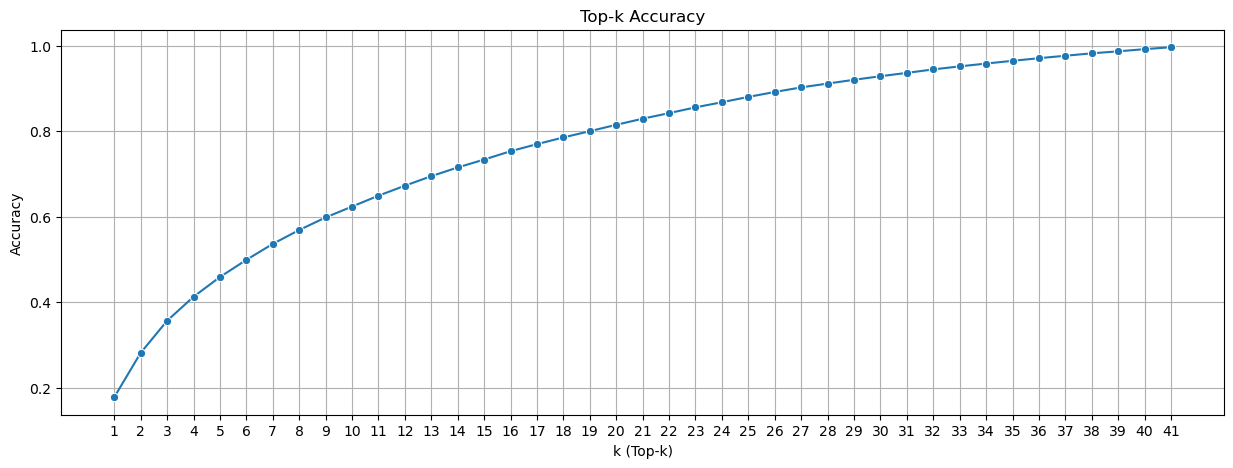

Mean Reciprocal Rank (MRR): 0.31924637168949777


In [60]:
# 4. Plot Top-k Accuracy for k = 1 to 10.
k_values = list(range(1, 42))
topk_accuracies = [top_k_accuracy(df_test, k) for k in k_values]


plt.figure(figsize=(15, 5))
sns.lineplot(x=k_values, y=topk_accuracies, marker="o")
plt.xlabel("k (Top-k)")
plt.ylabel("Accuracy")
plt.title("Top-k Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

mrr = mean_reciprocal_rank(df_test)
print("Mean Reciprocal Rank (MRR):", mrr)

In [75]:
topk_accuracies

[0.17730157972605354,
 0.28103374218488997,
 0.35610652412542354,
 0.4123037273898726,
 0.4584784994988784,
 0.49859208705197344,
 0.5360330262969503,
 0.568486612895528,
 0.597885744284828,
 0.6233236290745955,
 0.6488092397270081,
 0.6720994606977521,
 0.6944590273469193,
 0.7148379706963204,
 0.7333317424712452,
 0.7528277573617144,
 0.769388631699518,
 0.7850665775783897,
 0.7996706915477497,
 0.814632749486947,
 0.8288789194864697,
 0.8419558058511908,
 0.8554622249797165,
 0.8674175535722808,
 0.8798501407912948,
 0.8914475254140218,
 0.9021381186464945,
 0.9111105808237484,
 0.9198921395504224,
 0.9282918913759366,
 0.9360950699183888,
 0.9442561924306782,
 0.9512718942394883,
 0.9579057891471389,
 0.964324917672887,
 0.9704099651601202,
 0.9762325204028063,
 0.9818164463322675,
 0.9865174438027967,
 0.9916241111058083,
 0.9961342051257577]

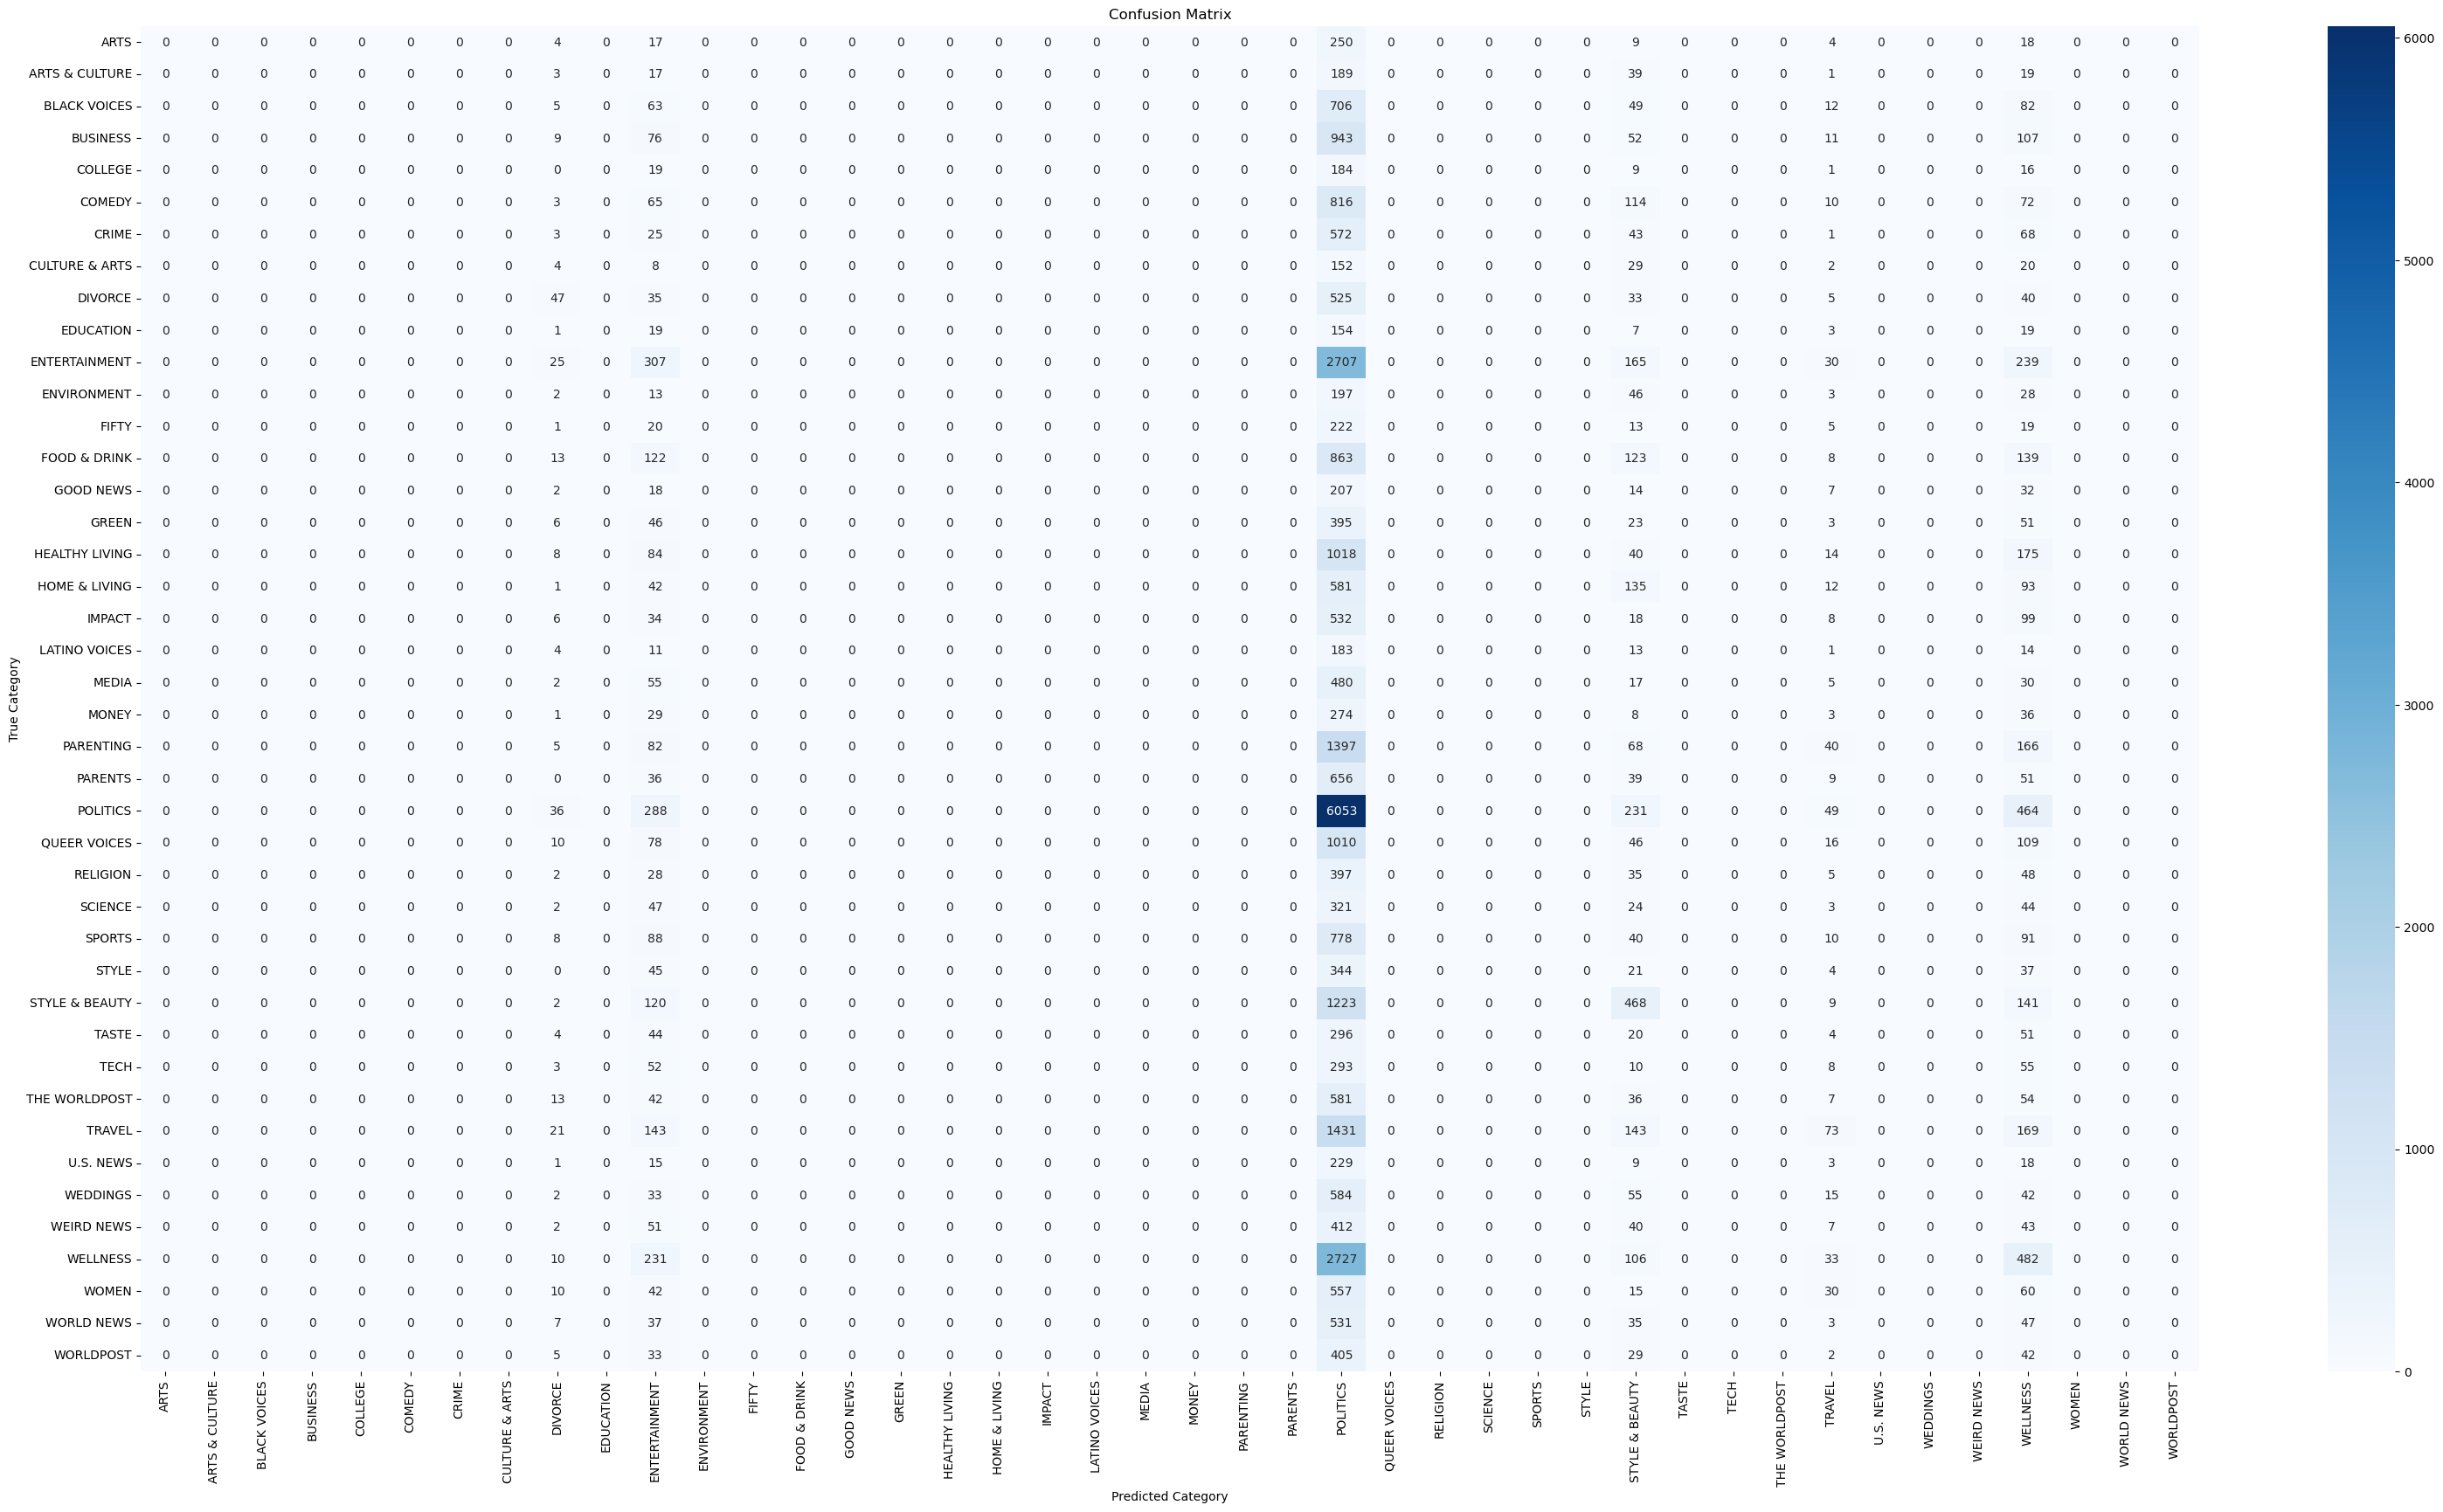

In [44]:
from sklearn.metrics import confusion_matrix


# Step 1. Extract the top prediction for each document.
df_test['predicted_top'] = df_test['ranked_prediction'].apply(lambda preds: preds[0] if isinstance(preds, list) and preds else None)
# Step 2. Compute the confusion matrix.
# Get a sorted list of unique categories from the true labels.
labels = sorted(df_test['category'].unique())

# Compute the confusion matrix using sklearn
cm = confusion_matrix(df_test['category'], df_test['predicted_top'], labels=labels)

# Step 3. Create a DataFrame for the confusion matrix.
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

# Step 4. Plot the confusion matrix using Seaborn.
plt.figure(figsize=(38, 20))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.show()

In [236]:
def mean_reciprocal_rank(df):
    def reciprocal_rank(row):
        try:
            # Find the index of the true category in the ranked predictions.
            # +1 because ranks are 1-indexed (first position is rank 1)
            rank = row['ranked_prediction'].index(row['category']) + 1
            return 1.0 / rank
        except ValueError:
            return 0.0
    return df.apply(reciprocal_rank, axis=1).mean()

mrr = mean_reciprocal_rank(df_test)
print("Mean Reciprocal Rank (MRR):", mrr)

Mean Reciprocal Rank (MRR): 0.3304573337657567
